In [2]:
import sklearn
import xgboost
import lightgbm

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)

print("\nAll required ML libraries are ready!")

scikit-learn: 1.9.0
XGBoost: 3.2.0
LightGBM: 4.7.0

All required ML libraries are ready!


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=-1
    )
}

print("4 models are ready!")

4 models are ready!


In [4]:
# Train all models

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

print("\nAll 4 models trained!")

NameError: name 'X_train' is not defined

In [5]:
from sklearn.model_selection import train_test_split

# Split the preprocessed data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Train/Test split completed!")

NameError: name 'X' is not defined

In [6]:
# Load the dataset
import pandas as pd

df = pd.read_csv("customer-churn-training.csv")

# Separate features and target
X = df.drop("churned", axis=1)
y = df["churned"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)
print("X and y created successfully!")

Features (X): (12, 6)
Target (y): (12,)
X and y created successfully!


In [7]:
from sklearn.model_selection import train_test_split

# Split data before preprocessing to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Train/Test split completed!")

X_train: (9, 6)
X_test: (3, 6)
y_train: (9,)
y_test: (3,)
Train/Test split completed!


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify columns
numeric_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

categorical_features = [
    "plan_type"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed!")
print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape:", X_test_processed.shape)

Preprocessing completed!
X_train processed shape: (9, 7)
X_test processed shape: (3, 7)


In [9]:
# Train all models on preprocessed data

trained_models = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

print("\nAll 4 models trained successfully!")

Logistic Regression trained successfully!
Random Forest trained successfully!
XGBoost trained successfully!
LightGBM trained successfully!

All 4 models trained successfully!


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print("MODEL COMPARISON")
display(results_df.round(3))

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.000,1.0,1.0,1.0,1.0
1,Random Forest,1.000,1.0,1.0,1.0,1.0
2,XGBoost,0.667,0.0,0.0,0.0,0.5
3,LightGBM,0.667,0.0,0.0,0.0,0.5


Dataset shape: (12, 7)

Columns:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']

Training samples: 9
Testing samples: 3

================ MODEL COMPARISON ================



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.000,1.0,1.0,1.0,1.0
1,Random Forest,1.000,1.0,1.0,1.0,1.0
2,XGBoost,0.667,0.0,0.0,0.0,0.5
3,LightGBM,0.667,0.0,0.0,0.0,0.5



================ STRATIFIED K-FOLD RESULTS ================



,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,1.0,0.0
1,Random Forest,1.0,0.0
2,XGBoost,0.5,0.0
3,LightGBM,0.5,0.0



================ TUNING RESULTS ================

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

Best CV ROC-AUC:
1.0

================ TUNED RANDOM FOREST ================

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
ROC-AUC: 1.0

Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



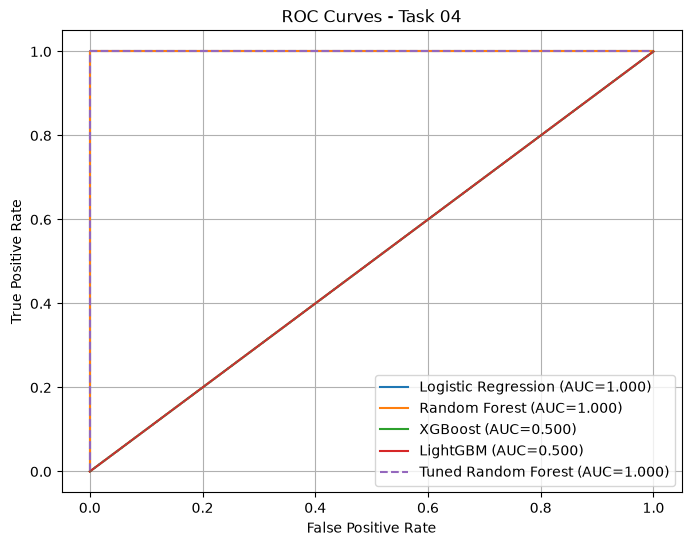


================ CHAMPION MODEL ================

Champion Model: Tuned Random Forest
Selection basis: ROC-AUC with supporting precision, recall and F1-score.
Champion model saved successfully!

================ TASK 04 COMPLETE ================

✓ Four classification models trained
✓ Accuracy, Precision, Recall and F1 evaluated
✓ ROC-AUC calculated
✓ Stratified K-Fold validation completed
✓ Random Forest hyperparameter tuning completed
✓ ROC curves generated
✓ Champion model selected
✓ Champion model serialized


In [13]:
# ============================================================
# TASK 04 - SUPERVISED MODELING & TUNING
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("customer-churn-training.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. FEATURES AND TARGET
# ============================================================

X = df.drop("churned", axis=1)
y = df["churned"]

# Remove customer identifier
X = X.drop("customer_id", axis=1)


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 4. COLUMN TYPES
# ============================================================

numeric_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

categorical_features = [
    "plan_type"
]


# ============================================================
# 5. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# ============================================================
# 6. FOUR CLASSIFICATION MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=-1
    )
}


# ============================================================
# 7. TRAIN AND EVALUATE FOUR MODELS
# ============================================================

results = []
trained_models = {}

for name, classifier in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_prob
        )
    })

    trained_models[name] = pipeline


results_df = pd.DataFrame(results)

print("\n================ MODEL COMPARISON ================\n")
display(results_df.round(3))


# ============================================================
# 8. STRATIFIED K-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, pipeline in trained_models.items():

    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)

        val_prob = pipeline.predict_proba(X_val)[:, 1]

        scores.append(
            roc_auc_score(y_val, val_prob)
        )

    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": np.mean(scores),
        "CV ROC-AUC Std": np.std(scores)
    })


cv_df = pd.DataFrame(cv_results)

print("\n================ STRATIFIED K-FOLD RESULTS ================\n")
display(cv_df.round(3))


# ============================================================
# 9. HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [None, 3, 5],
    "classifier__min_samples_split": [2, 3]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n================ TUNING RESULTS ================\n")
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(grid_search.best_score_, 3))


# ============================================================
# 10. TUNED MODEL EVALUATION
# ============================================================

tuned_model = grid_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]

print("\n================ TUNED RANDOM FOREST ================\n")

print("Accuracy:",
      round(accuracy_score(y_test, tuned_pred), 3))

print("Precision:",
      round(precision_score(
          y_test, tuned_pred, zero_division=0
      ), 3))

print("Recall:",
      round(recall_score(
          y_test, tuned_pred, zero_division=0
      ), 3))

print("F1-Score:",
      round(f1_score(
          y_test, tuned_pred, zero_division=0
      ), 3))

print("ROC-AUC:",
      round(roc_auc_score(
          y_test, tuned_prob
      ), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_pred,
    zero_division=0
))


# ============================================================
# 11. ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for name, pipeline in trained_models.items():

    prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc_score = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

# Tuned Random Forest
fpr, tpr, _ = roc_curve(
    y_test,
    tuned_prob
)

tuned_auc = roc_auc_score(
    y_test,
    tuned_prob
)

plt.plot(
    fpr,
    tpr,
    linestyle="--",
    label=f"Tuned Random Forest (AUC={tuned_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Task 04")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 12. CHAMPION MODEL
# ============================================================

champion_name = "Tuned Random Forest"
champion_model = tuned_model

print("\n================ CHAMPION MODEL ================\n")
print("Champion Model:", champion_name)
print("Selection basis: ROC-AUC with supporting precision, recall and F1-score.")


# ============================================================
# 13. SAVE CHAMPION MODEL
# ============================================================

import joblib

joblib.dump(
    champion_model,
    "task06_api/task04_champion_model.joblib"
)

print("Champion model saved successfully!")

# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n================ TASK 04 COMPLETE ================\n")
print("✓ Four classification models trained")
print("✓ Accuracy, Precision, Recall and F1 evaluated")
print("✓ ROC-AUC calculated")
print("✓ Stratified K-Fold validation completed")
print("✓ Random Forest hyperparameter tuning completed")
print("✓ ROC curves generated")
print("✓ Champion model selected")
print("✓ Champion model serialized")

['task04_champion_model.joblib']